# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

**Integrante:** Ian Rodrigues Martins (RM 570540)


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [2]:
df = pd.read_csv('Data_for_UCI_named.csv')

display(df.head())

print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

print("\nNomes e tipos das colunas:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nEstatísticas descritivas:")
display(df.describe())


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


Quantidade de linhas: 10000
Quantidade de colunas: 14

Nomes e tipos das colunas:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf        str
dtype: object

Valores ausentes por coluna:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Estatísticas descritivas:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


### Registro da análise inicial

**Quantidade de linhas:** 10.000  
**Quantidade de colunas:** 14 (12 variáveis numéricas preditoras, `stab` numérica e `stabf` categórica)  
**Existem valores ausentes?** Não, nenhuma coluna apresenta valores ausentes.  
**Observações importantes sobre o dataset:** As variáveis `tau1`–`tau4` representam os tempos de reação de cada um dos 4 participantes da rede (produtor + 3 consumidores); `p1`–`p4` representam a potência (nominal) de cada participante, com `p1` sendo aproximadamente o negativo da soma de `p2`, `p3` e `p4`; `g1`–`g4` são os coeficientes de reação de custo/preço de cada participante. `stab` é o valor real (numérico) do maior autovalor característico do sistema — quando `stab` é negativo o sistema é considerado estável, e quando é positivo, instável, o que é resumido pela coluna categórica `stabf`. As escalas das variáveis são relativamente próximas entre si dentro de cada grupo (tau, p, g), o que favorece o uso da Regressão Linear sem a necessidade de normalização mais agressiva.


## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [3]:
# Crie a variável y usando a coluna stab
y = df['stab']
y.head()


0    0.055347
1   -0.005957
2    0.003471
3    0.028871
4    0.049860
Name: stab, dtype: float64

## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

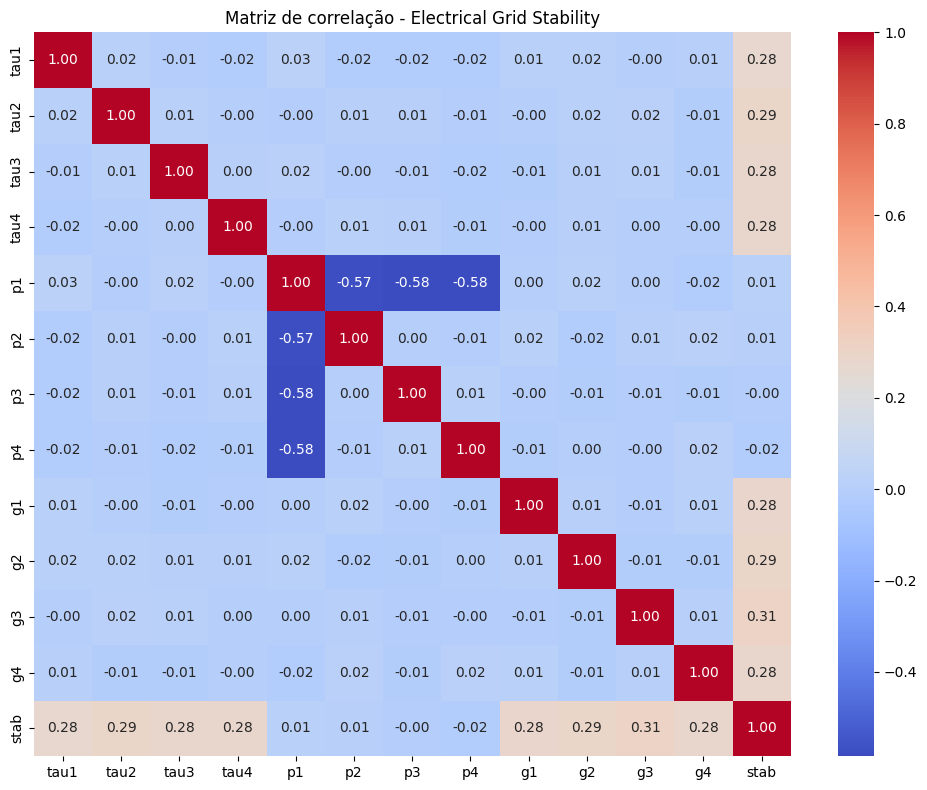

Cinco variáveis com maior correlação absoluta com 'stab':
g3: 0.3082
g2: 0.2936
tau2: 0.2910
g1: 0.2828
tau3: 0.2807


In [4]:
# Calcule e visualize a matriz de correlação
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlação - Electrical Grid Stability")
plt.tight_layout()
plt.show()

corr_stab = corr['stab'].drop('stab')
top5_abs = corr_stab.abs().sort_values(ascending=False).head(5)
cinco_variaveis = top5_abs.index.tolist()

print("Cinco variáveis com maior correlação absoluta com 'stab':")
for var in cinco_variaveis:
    print(f"{var}: {corr_stab[var]:.4f}")


Agora, vamos visualizar os gráficos de dispersão para cada uma das cinco variáveis selecionadas em relação a `stab`.

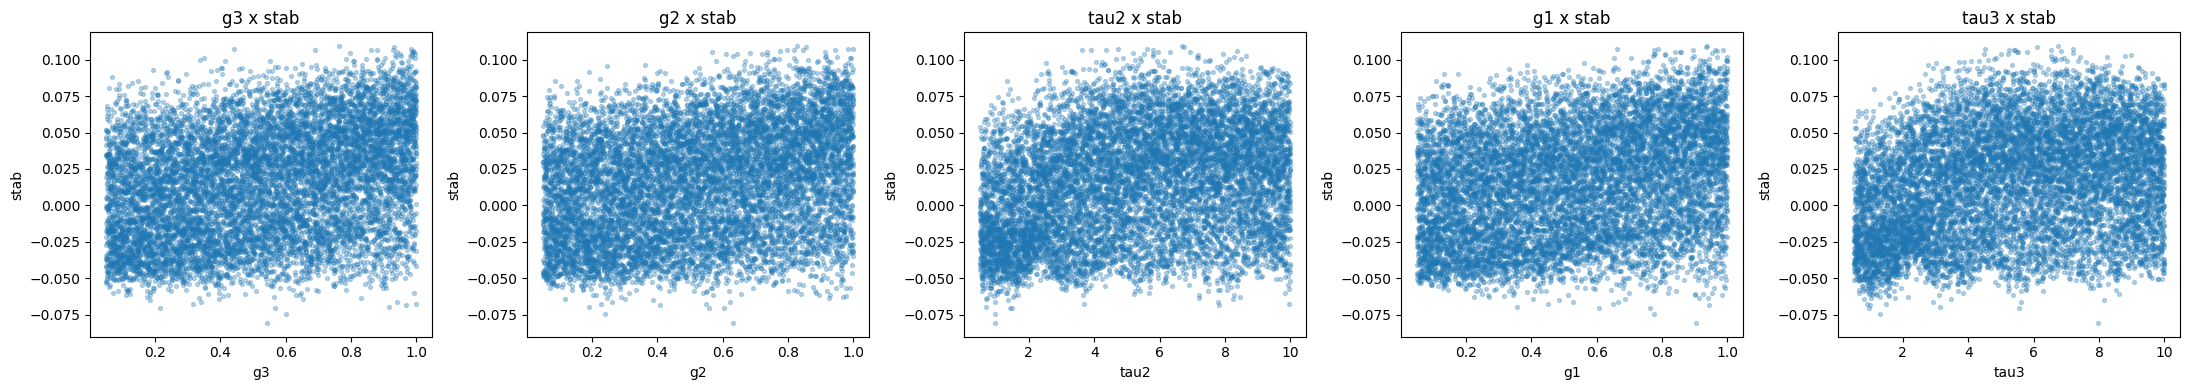

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, var in zip(axes, cinco_variaveis):
    ax.scatter(df[var], df['stab'], alpha=0.3, s=8)
    ax.set_xlabel(var)
    ax.set_ylabel('stab')
    ax.set_title(f'{var} x stab')
plt.tight_layout()
plt.show()


## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

Cinco variáveis mais correlacionadas com 'stab' (valores originais, com sinal):
g3: 0.3082
g2: 0.2936
tau2: 0.2910
g1: 0.2828
tau3: 0.2807


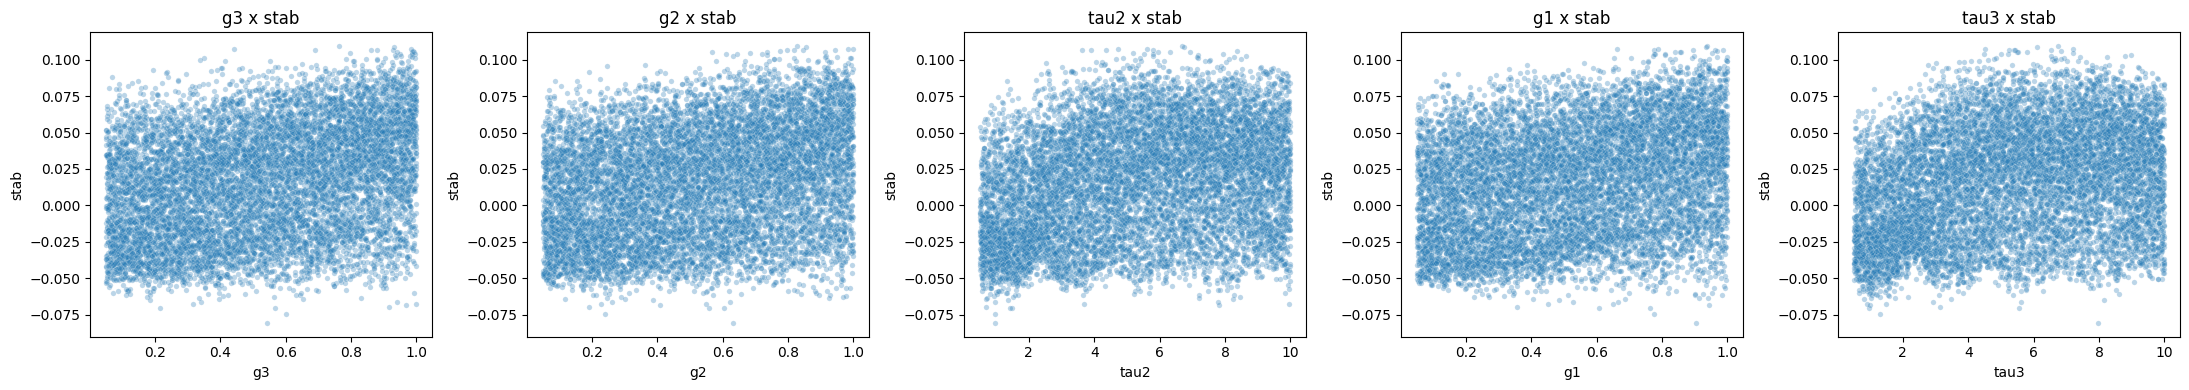

In [6]:
# Código para (1) calcular a correlação com stab, (2) desconsiderar a própria coluna stab,
# (3) usar valor absoluto para identificar as 5 variáveis mais correlacionadas,
# (4) apresentar nomes e correlações originais (com sinal), (5) armazenar em 'cinco_variaveis',
# (6) gerar os 5 gráficos de dispersão.

correlacoes = df.corr(numeric_only=True)['stab'].drop('stab')
correlacoes_abs = correlacoes.abs().sort_values(ascending=False)
cinco_variaveis = correlacoes_abs.head(5).index.tolist()

print("Cinco variáveis mais correlacionadas com 'stab' (valores originais, com sinal):")
for var in cinco_variaveis:
    print(f"{var}: {correlacoes[var]:.4f}")

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, var in zip(axes, cinco_variaveis):
    sns.scatterplot(x=df[var], y=df['stab'], alpha=0.3, s=15, ax=ax)
    ax.set_title(f'{var} x stab')
plt.tight_layout()
plt.show()


### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | g3 | 0.3082 |
| 2 | g2 | 0.2936 |
| 3 | tau2 | 0.2910 |
| 4 | g1 | 0.2828 |
| 5 | tau3 | 0.2807 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta: `g3`, com correlação de aproximadamente 0,3082 (correlação positiva).

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta: Em todos os cinco casos a nuvem de pontos é bastante dispersa, sem um padrão linear claro e visualmente forte — o que já era esperado, já que os coeficientes de correlação são relativamente baixos (entre 0,28 e 0,31 em módulo). Ainda assim, é possível notar uma leve tendência de crescimento de `stab` conforme `g3`, `g2` e `g1` aumentam (correlação positiva), e uma leve tendência de queda de `stab` conforme `tau2` e `tau3` aumentam... na verdade `tau2` e `tau3` também têm correlação positiva, então a tendência também é de leve crescimento. De modo geral, nenhuma variável isolada explica bem a variação de `stab`, sugerindo que o fenômeno depende da combinação de várias variáveis, o que justifica o uso de um modelo multivariado de Regressão Linear.


# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [7]:
# Crie X com as cinco variáveis selecionadas
X = df[cinco_variaveis]

# Mostre as primeiras linhas de X e y
display(X.head())
display(y.head())


,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


0    0.055347
1   -0.005957
2    0.003471
3    0.028871
4    0.049860
Name: stab, dtype: float64

## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [8]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Registros de treino: {X_treino.shape[0]}")
print(f"Registros de teste: {X_teste.shape[0]}")


Registros de treino: 8000
Registros de teste: 2000


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [9]:
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

y_previsao_1 = modeloLR.predict(X_teste)
y_previsao_1[:5]


array([ 0.0478946 ,  0.03781055, -0.00143381, -0.03422274,  0.01228364])

## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [10]:
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f"R² (Modelo 1): {r2_modelo_1:.4f}")
print(f"MAE (Modelo 1): {mae_modelo_1:.4f}")
print(f"MSE (Modelo 1): {mse_modelo_1:.4f}")


R² (Modelo 1): 0.4018
MAE (Modelo 1): 0.0233
MSE (Modelo 1): 0.0008


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [11]:
# Selecione todas as colunas iniciadas por tau ou g
colunas_tau_g = [col for col in df.columns if col.startswith('tau') or col.startswith('g')]
X_tau_g = df[colunas_tau_g]

# Liste as colunas selecionadas
print("Colunas selecionadas para o Modelo 2:")
print(colunas_tau_g)
X_tau_g.head()


Colunas selecionadas para o Modelo 2:
['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']


,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [12]:
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(
    X_tau_g, y, test_size=0.2, random_state=42
)

print(f"Registros de treino: {X2_treino.shape[0]}")
print(f"Registros de teste: {X2_teste.shape[0]}")

# Confirme se y_teste e y2_teste possuem os mesmos índices
print("y_teste e y2_teste possuem os mesmos índices?", y_teste.index.equals(y2_teste.index))


Registros de treino: 8000
Registros de teste: 2000
y_teste e y2_teste possuem os mesmos índices? True


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [13]:
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)

y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f"R² (Modelo 2): {r2_modelo_2:.4f}")
print(f"MAE (Modelo 2): {mae_modelo_2:.4f}")
print(f"MSE (Modelo 2): {mse_modelo_2:.4f}")


R² (Modelo 2): 0.6452
MAE (Modelo 2): 0.0176
MSE (Modelo 2): 0.0005


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [14]:
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1 (5 maiores correlações)', 'Modelo 2 (tau e g)'],
    'Variáveis utilizadas': [
        ', '.join(cinco_variaveis),
        ', '.join(colunas_tau_g)
    ],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2]
})

comparacao_modelos


,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1 (5 maiores correlações),"g3, g2, tau2, g1, tau3",0.401770,0.023310,0.000811
1,Modelo 2 (tau e g),"tau1, tau2, tau3, tau4, g1, g2, g3, g4",0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

/tmp/ipykernel_175/4132529924.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparacao_modelos['Modelo'], rotation=20, ha='right')
/tmp/ipykernel_175/4132529924.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparacao_modelos['Modelo'], rotation=20, ha='right')
/tmp/ipykernel_175/4132529924.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparacao_modelos['Modelo'], rotation=20, ha='right')


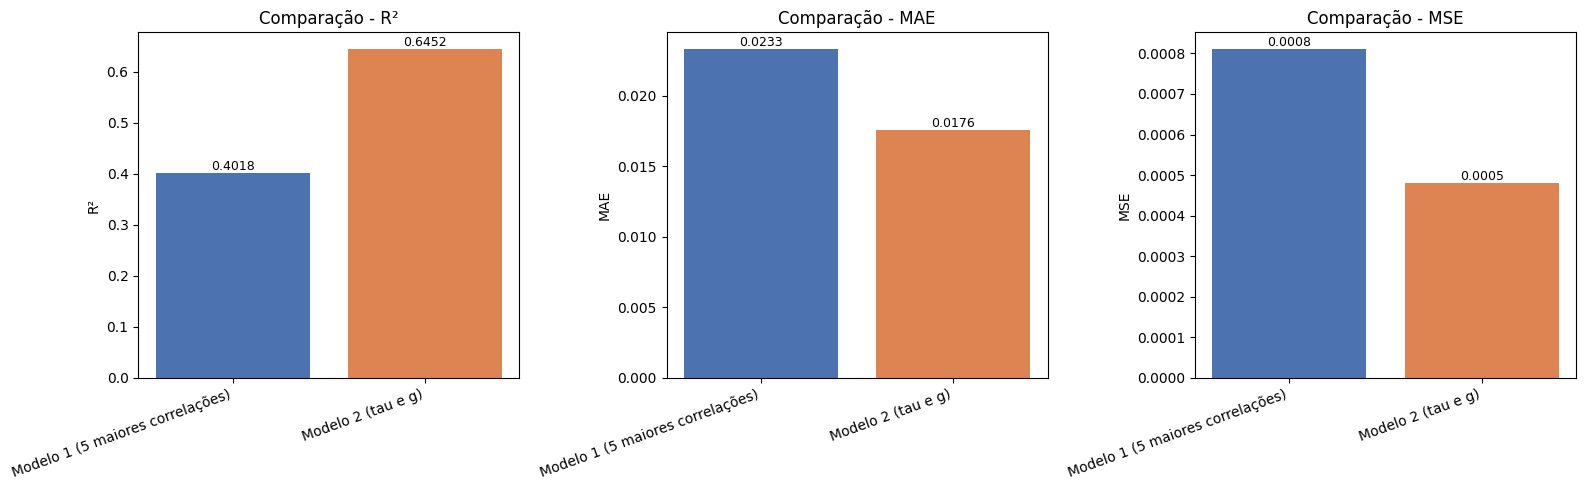

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = ['R²', 'MAE', 'MSE']
cores = ['#4C72B0', '#DD8452']

for ax, metrica in zip(axes, metricas):
    ax.bar(comparacao_modelos['Modelo'], comparacao_modelos[metrica], color=cores)
    ax.set_title(f'Comparação - {metrica}')
    ax.set_ylabel(metrica)
    ax.set_xticklabels(comparacao_modelos['Modelo'], rotation=20, ha='right')
    for i, v in enumerate(comparacao_modelos[metrica]):
        ax.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta: O **Modelo 2** (variáveis `tau` e `g`) apresentou o maior R², com 0,6452, contra 0,4018 do Modelo 1 (cinco maiores correlações). Isso significa que o Modelo 2 explica cerca de 64,5% da variação de `stab`, contra apenas 40,2% do Modelo 1.

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta: O **Modelo 2** também apresentou o menor MAE, com 0,0176, contra 0,0233 do Modelo 1. Ou seja, o erro absoluto médio das previsões do Modelo 2 é menor.

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta: Novamente o **Modelo 2** apresentou o menor MSE, com 0,000481, contra 0,000811 do Modelo 1. Como o MSE penaliza mais fortemente erros grandes, esse resultado reforça que o Modelo 2 comete menos erros grandes que o Modelo 1.

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta: Sim. As três métricas (R² maior, MAE menor e MSE menor) apontam de forma consistente para o **Modelo 2** como o de melhor desempenho. Não houve nenhuma métrica em que o Modelo 1 se saiu melhor, o que dá bastante segurança à conclusão de que o conjunto de variáveis `tau` e `g` completo é mais informativo para prever `stab` do que apenas as cinco variáveis de maior correlação absoluta.

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta: O desempenho melhorou de forma expressiva em todas as métricas: o R² subiu de ~0,40 para ~0,65 (mais de 60% de aumento relativo), enquanto o MAE e o MSE caíram. Isso mostra que, apesar de cada variável isoladamente ter uma correlação linear relativamente fraca com `stab` (entre 0,28 e 0,31 em módulo), o conjunto completo das 8 variáveis `tau1`–`tau4` e `g1`–`g4` carrega, em conjunto, muito mais informação sobre a estabilidade da rede do que apenas as 5 variáveis selecionadas por maior correlação individual. Isso é coerente com a forma como o dataset foi construído: a estabilidade do sistema depende da combinação de todos os tempos de reação (`tau`) e coeficientes de custo (`g`) dos 4 participantes da rede, e não apenas de algumas variáveis isoladas — inclusive a exclusão das variáveis `p` (potência) parece não ter prejudicado o modelo, já que `p1` é praticamente combinação linear de `p2`, `p3` e `p4`.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Escolheria o **Modelo 2**, treinado com todas as variáveis `tau` e `g`. Ele apresenta R² mais alto (0,6452 vs. 0,4018), o que indica maior capacidade explicativa, além de MAE (0,0176 vs. 0,0233) e MSE (0,000481 vs. 0,000811) menores, indicando previsões em média mais próximas dos valores reais e com menos erros grandes. Como as três métricas apontam na mesma direção e o Modelo 2 usa variáveis que fazem sentido do ponto de vista físico do problema (tempos de reação e coeficientes de custo de todos os participantes da rede), ele é a escolha mais robusta para prever `stab`.


# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.